# Policy gradients and REINFORCE

### Optimising the thing you deploy, and paying for it in variance

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why some problems have no good deterministic policy, how the log-derivative trick turns "differentiate an expectation over trajectories" into something you can sample, and why REINFORCE is correct on average and still barely works until you cut its variance three ways |
| **You should already know** | [11-04 Q-learning](../04-q-learning/) and [11-06 Deep Q-Networks](../06-deep-q-networks/), plus enough PyTorch to read a two-layer network |
| **Environment** | Cart-pole, the same from-scratch physics as [11-06](../06-deep-q-networks/), on purpose, so the two notebooks can be put side by side. No `gymnasium` needed |
| **Runtime** | Around five minutes on a laptop CPU |
| **Next** | [11-08 Actor-critic and PPO](../08-actor-critic-and-ppo/) |

---

## 1. Why optimise the policy directly

The two agents before this one learned a number and derived their behaviour from
it. [Q-learning](../04-q-learning/) filled a table of $Q(s,a)$ and acted by
`argmax`. [DQN](../06-deep-q-networks/) replaced the table with a network and
acted by `argmax` on its output. In both, the policy was a consequence of the
value function, never something that was optimised in its own right.

That indirection costs three things.

**An `argmax` is always deterministic.** Whatever numbers a value function
produces, taking the largest gives one action per state with probability one. If
the best available behaviour requires a coin flip, no value function can express
it.

**An `argmax` over a continuous action is an optimisation problem.** With two
push directions you compare two numbers. With a steering angle you would have to
solve $\max_a Q(s,a)$ over a continuum, inside every single step, of both
training and deployment.

**An `argmax` is discontinuous.** A tiny change in the weights can flip the
preferred action in a whole region of state space, so a smooth improvement in the
value estimate can produce a jump in behaviour.

The alternative is to parameterise the policy itself — write $\pi_\theta(a \mid
s)$ as a network with a probability distribution on its output — and push
$\theta$ in whatever direction increases expected return. That is the whole idea.
The rest of this notebook is about the fact that the direction is expensive to
estimate.

### A problem with no good deterministic answer

The first cost is easiest to see in a corridor of three states. The agent's
sensors report the same thing in all three, so any policy it can represent must
use the same action probabilities in all three. In the middle state, the actions
are wired backwards: asking to go right sends you left. There is a wall on the
far left and the exit on the far right, and every step costs one.

I will solve this one exactly rather than learn it, because the point is about
what is representable, not about what is learnable.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

In [2]:
def corridor_expected_steps(p):
    """Expected steps to the exit when 'right' is chosen with probability p everywhere.

    Three states, all reporting the same observation, so one p has to serve for
    all of them. State 1 has its actions reversed. The expected-cost equations

        v0 = 1 + p*v1 + (1-p)*v0     (a wall on the left)
        v1 = 1 + p*v0 + (1-p)*v2     (reversed)
        v2 = 1 + p*0  + (1-p)*v1     (right leaves through the exit)

    are linear in v, so I solve them instead of simulating them.
    """
    A = np.eye(3)
    A[0, 0] -= (1 - p)
    A[0, 1] -= p
    A[1, 0] -= p
    A[1, 2] -= (1 - p)
    A[2, 1] -= (1 - p)
    return float(np.linalg.solve(A, np.ones(3))[0])


probabilities = np.linspace(0.02, 0.98, 241)
cost = np.array([corridor_expected_steps(p) for p in probabilities])
best = int(np.argmin(cost))
p_best = probabilities[best]

print("always right (p = 1.00) : never exits, the loop between S0 and S1 is absorbing")
print("always left  (p = 0.00) : never exits, the wall on the left holds it at S0")
print(f"p = 0.05                : {corridor_expected_steps(0.05):8.1f} steps")
print(f"p = 0.95                : {corridor_expected_steps(0.95):8.1f} steps")
print(f"best mixture p = {p_best:.2f}      : {cost[best]:8.1f} steps")

always right (p = 1.00) : never exits, the loop between S0 and S1 is absorbing
always left  (p = 0.00) : never exits, the wall on the left holds it at S0
p = 0.05                :     82.1 steps
p = 0.95                :     44.2 steps
best mixture p = 0.58      :     11.7 steps


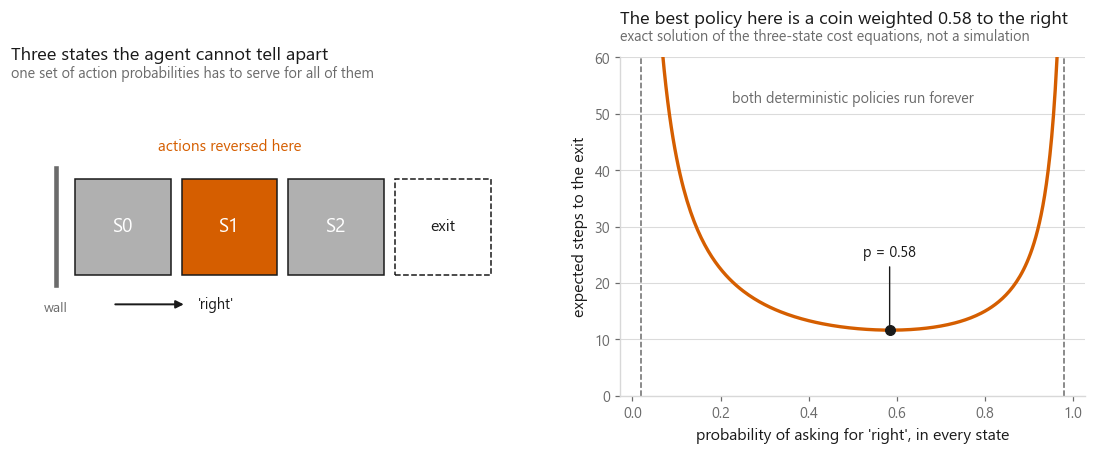

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.0),
                         gridspec_kw={"width_ratios": [1.1, 1]})

ax = axes[0]
for i in range(3):
    ax.add_patch(plt.Rectangle((i, 0), 0.9, 0.9, lw=1.0, edgecolor=style.INK,
                               facecolor=style.HIGHLIGHT if i == 1 else style.NEUTRAL))
    ax.text(i + 0.45, 0.45, f"S{i}", ha="center", va="center", fontsize=12.5, color="white")
ax.add_patch(plt.Rectangle((3, 0), 0.9, 0.9, lw=1.0, ls="--",
                           edgecolor=style.INK, facecolor="white"))
ax.text(3.45, 0.45, "exit", ha="center", va="center", fontsize=10.5, color=style.INK)
ax.plot([-0.18, -0.18], [-0.1, 1.0], color=style.MUTED, lw=3.0)
ax.text(-0.18, -0.35, "wall", ha="center", fontsize=9, color=style.MUTED)
ax.text(1.45, 1.16, "actions reversed here", ha="center", fontsize=10, color=style.HIGHLIGHT)
ax.annotate("", xy=(1.05, -0.28), xytext=(0.35, -0.28),
            arrowprops=dict(arrowstyle="-|>", color=style.INK, lw=1.3))
ax.text(1.15, -0.28, "'right'", va="center", fontsize=9.5, color=style.INK)
ax.set_xlim(-0.6, 4.2)
ax.set_ylim(-0.8, 1.7)
ax.set_aspect("equal")
ax.set_axis_off()
style.title(ax, "Three states the agent cannot tell apart",
            "one set of action probabilities has to serve for all of them")

ax = axes[1]
ax.plot(probabilities, cost, color=style.HIGHLIGHT, lw=2.2)
ax.scatter([p_best], [cost[best]], color=style.INK, s=42, zorder=5)
ax.annotate(f"p = {p_best:.2f}", xy=(p_best, cost[best]), xytext=(p_best, cost[best] + 13),
            ha="center", fontsize=9.5, color=style.INK,
            arrowprops=dict(arrowstyle="-", color=style.INK, lw=0.9))
for edge in (0.02, 0.98):
    ax.axvline(edge, color=style.MUTED, lw=1.0, ls="--")
ax.text(0.5, 52, "both deterministic policies run forever",
        ha="center", fontsize=9.5, color=style.MUTED)
ax.set_xlabel("probability of asking for 'right', in every state")
ax.set_ylabel("expected steps to the exit")
ax.set_ylim(0, 60)
style.title(ax, f"The best policy here is a coin weighted {p_best:.2f} to the right",
            "exact solution of the three-state cost equations, not a simulation")
style.save(fig, FIG / "fig-01-stochastic-optimum.png")

The curve has its minimum strictly inside the interval and rises to infinity at
both ends. Committing to one action forever is the worst thing the agent can do,
and those two ends are the only policies an `argmax` over a value function can
produce here. Randomness is not exploration in this problem, it is the answer.

Aliased states are not an exotic case. They appear whenever the agent's input is
a partial view of the world, and they appear whenever a function approximator is
too small to separate two states that need different actions — which is most of
the time, on real problems.

### What a parameterised policy looks like

For a discrete action set, put a softmax on the network's output and you have a
distribution. For a continuous action, have the network emit a mean and a log
standard deviation and sample from a Gaussian. Both are differentiable in
$\theta$, and neither needs a `max` over actions anywhere.

In [4]:
torch.manual_seed(SEED)
demo_state = torch.tensor([[0.0, 0.0, 0.10, 0.0]])   # leaning right, standing still

discrete = nn.Linear(4, 2)                # two logits, one per push direction
continuous = nn.Linear(4, 2)              # a mean and a log standard deviation

with torch.no_grad():
    probs = torch.softmax(discrete(demo_state), dim=1)[0]
    mean, log_std = continuous(demo_state)[0]
    gaussian = torch.distributions.Normal(mean, log_std.exp())
    sampled = gaussian.sample((4,))

print(f"discrete policy   : push left {probs[0]:.3f}, push right {probs[1]:.3f}")
print(f"continuous policy : mean {mean:+.3f}, std {log_std.exp():.3f}")
print(f"four sampled forces: {np.round(sampled.numpy(), 3)}")
print(f"log density of the first sample: {gaussian.log_prob(sampled[0]):.3f}")
print("\nnothing here needed a max over actions, which is the point")

discrete policy   : push left 0.446, push right 0.554
continuous policy : mean -0.387, std 0.820
four sampled forces: [-0.876 -0.237 -1.09   0.516]
log density of the first sample: -0.899

nothing here needed a max over actions, which is the point


### The environment

Cart-pole, and deliberately the same cart-pole as
[11-06](../06-deep-q-networks/): identical constants, identical Euler
integration, identical failure angles. I copied the class across unchanged so
that the numbers at the end of this notebook can be put next to the numbers at
the end of that one without an argument about the physics.

Four real numbers describe the state — cart position, cart velocity, pole angle,
pole angular velocity. Two actions push the cart. Every tick survived pays +1.

In [5]:
class CartPole:
    """The cart-pole from 11-06, copied unchanged so the two notebooks compare.

    `step` returns (state, reward, done). `done` means the pole fell or the cart
    ran off the track — it never means "we hit the time limit", because the
    caller owns the time limit.
    """

    gravity = 9.8
    mass_cart = 1.0
    mass_pole = 0.1
    length = 0.5              # half the pole; the equations are written in half-lengths
    force_mag = 10.0
    tau = 0.02                # seconds per tick
    x_limit = 2.4
    angle_limit = 12.0 * np.pi / 180.0

    n_features = 4
    n_actions = 2

    def __init__(self, rng=None):
        self.rng = np.random.default_rng(SEED) if rng is None else rng
        self.state = np.zeros(4)

    def reset(self):
        self.state = self.rng.uniform(-0.05, 0.05, size=4)
        return self.state.astype(np.float32)

    def step(self, action):
        x, x_dot, theta, theta_dot = self.state
        force = self.force_mag if action == 1 else -self.force_mag
        cos_t, sin_t = np.cos(theta), np.sin(theta)

        total_mass = self.mass_cart + self.mass_pole
        pole_ml = self.mass_pole * self.length

        temp = (force + pole_ml * theta_dot ** 2 * sin_t) / total_mass
        theta_acc = ((self.gravity * sin_t - cos_t * temp)
                     / (self.length * (4.0 / 3.0 - self.mass_pole * cos_t ** 2 / total_mass)))
        x_acc = temp - pole_ml * theta_acc * cos_t / total_mass

        x += self.tau * x_dot
        x_dot += self.tau * x_acc
        theta += self.tau * theta_dot
        theta_dot += self.tau * theta_acc
        self.state = np.array([x, x_dot, theta, theta_dot])

        done = bool(abs(x) > self.x_limit or abs(theta) > self.angle_limit)
        return self.state.astype(np.float32), 1.0, done


env = CartPole(np.random.default_rng(SEED))
s0 = env.reset()
s1, r1, d1 = env.step(1)
print(f"{env.n_features} continuous features, {env.n_actions} actions")
print(f"start state    : {np.round(s0, 4)}")
print(f"after one push : {np.round(s1, 4)}  reward {r1}  done {d1}")
print(f"failure at {np.degrees(env.angle_limit):.0f} degrees or {env.x_limit} metres, "
      "and the caller cuts episodes off at 500 ticks")

4 continuous features, 2 actions
start state    : [ 0.0137 -0.023  -0.0459 -0.0483]
after one push : [ 0.0132  0.1727 -0.0469 -0.3552]  reward 1.0  done False
failure at 12 degrees or 2.4 metres, and the caller cuts episodes off at 500 ticks


## 2. The estimator and the log-derivative trick

Write a trajectory as $\tau = (s_0, a_0, r_0, s_1, \dots)$ and its return as
$R(\tau)$. The policy induces a distribution over trajectories, and the thing to
maximise is the expected return under that distribution:

$$J(\theta) = \mathbb{E}_{\tau \sim p_\theta}\big[R(\tau)\big]
= \int p_\theta(\tau)\, R(\tau)\, d\tau$$

This looks impossible to differentiate by sampling. The samples themselves come
from the distribution being differentiated, so you cannot hold them fixed and
take a derivative of the integrand — moving $\theta$ moves the sampler.

### The trick

Push the gradient inside the integral and then use one identity:

$$\nabla_\theta \log p_\theta(\tau) = \frac{\nabla_\theta p_\theta(\tau)}{p_\theta(\tau)}
\qquad\Longrightarrow\qquad
\nabla_\theta p_\theta(\tau) = p_\theta(\tau)\, \nabla_\theta \log p_\theta(\tau)$$

That is the **log-derivative trick**, and it is nothing more than the chain rule
on $\log$, read right to left. It earns its name because of what it does to the
integral:

$$\nabla_\theta J = \int \nabla_\theta p_\theta(\tau)\, R(\tau)\, d\tau
= \int p_\theta(\tau)\, \nabla_\theta \log p_\theta(\tau)\, R(\tau)\, d\tau
= \mathbb{E}_{\tau \sim p_\theta}\big[R(\tau)\, \nabla_\theta \log p_\theta(\tau)\big]$$

The left side is a gradient of an expectation, which you cannot sample. The right
side is an expectation of a gradient, which you can: run the policy, look at what
happened, average.

### Why the dynamics drop out

The probability of a trajectory factorises into the start state, the policy's
choices, and the environment's responses:

$$\log p_\theta(\tau) = \log \rho(s_0)
+ \sum_t \log \pi_\theta(a_t \mid s_t)
+ \sum_t \log P(s_{t+1} \mid s_t, a_t)$$

Take $\nabla_\theta$ of that and two of the three terms vanish, because neither
the start distribution nor the physics depends on $\theta$. What is left is a sum
over the agent's own decisions:

$$\nabla_\theta J = \mathbb{E}\Big[\Big(\sum_t \nabla_\theta \log \pi_\theta(a_t \mid s_t)\Big) R(\tau)\Big]$$

No transition model appears anywhere. That is why this is a model-free method
even though the derivation started from a probability over whole trajectories.

### The policy gradient theorem, and REINFORCE

The theorem sharpens the statement: the weight attached to each decision is the
value of that decision, not the return of the entire trajectory.

$$\nabla_\theta J = \mathbb{E}\Big[\sum_t \nabla_\theta \log \pi_\theta(a_t \mid s_t)\;
Q^{\pi_\theta}(s_t, a_t)\Big]$$

**REINFORCE** is what you get when you refuse to learn $Q$ and use the sampled
return in its place. The estimator is unbiased because the sampled return is an
unbiased sample of $Q^{\pi}$, and it needs nothing except the ability to run the
policy and read a log probability.

One implementation note that trips people up. PyTorch minimises, and there is no
loss function here, so we write a **surrogate**: a scalar whose gradient happens
to be the negative of the estimator.

$$\mathcal{L}(\theta) = -\frac{1}{N}\sum_{\tau}\sum_t
\log \pi_\theta(a_t \mid s_t)\, w_t$$

The value of that scalar means nothing. Watching it go down tells you nothing.
Only its gradient is meaningful, and the whole notebook from here is about what
to put in $w_t$.

### Checking the trick on something with a known answer

Before trusting it on cart-pole, I check it on a one-step problem where the exact
gradient can be written down: two actions, a softmax over two parameters, and a
fixed payoff for each action. Exact derivative, central finite differences, and
the sampled score-function estimator should all agree.

In [6]:
def softmax(z):
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()


theta = np.array([0.30, -0.20])
payoff = np.array([1.0, 2.0])

pi = softmax(theta)
J = pi @ payoff
exact = pi * (payoff - J)                     # dJ/dtheta_i for a softmax over payoffs

eps = 1e-6
finite_diff = np.array([
    ((softmax(theta + eps * np.eye(2)[i]) @ payoff)
     - (softmax(theta - eps * np.eye(2)[i]) @ payoff)) / (2 * eps)
    for i in range(2)
])

rng = np.random.default_rng(SEED)
rows = [{"estimate": "exact", "d/dtheta_0": exact[0], "d/dtheta_1": exact[1], "samples": ""},
        {"estimate": "finite difference", "d/dtheta_0": finite_diff[0],
         "d/dtheta_1": finite_diff[1], "samples": ""}]

for n in (10, 1_000, 100_000):
    actions = rng.choice(2, size=n, p=pi)
    # grad log pi(a) for a softmax is one-hot(a) minus the probability vector
    scores = np.eye(2)[actions] - pi
    estimate = (payoff[actions][:, None] * scores).mean(axis=0)
    rows.append({"estimate": "score function", "d/dtheta_0": estimate[0],
                 "d/dtheta_1": estimate[1], "samples": f"{n:,}"})

print(pd.DataFrame(rows).round(4).to_string(index=False))
print("\nthe sampled estimator is unbiased, and ten samples still get it visibly wrong")

         estimate  d/dtheta_0  d/dtheta_1 samples
            exact     -0.2350      0.2350        
finite difference     -0.2350      0.2350        
   score function     -0.4337      0.4337      10
   score function     -0.2666      0.2666   1,000
   score function     -0.2338      0.2338 100,000

the sampled estimator is unbiased, and ten samples still get it visibly wrong


The last three rows are the story of this notebook in miniature. The estimator is
correct on average at every sample size. At ten samples it is also useless.

## 3. Unbiased, and very noisy — measured

Now the machinery on cart-pole. Everything below is deliberately small: a
two-layer policy with a tanh hidden layer, batches of a few episodes, and a
budget measured in environment steps rather than episodes so that every
configuration — and the DQN agent later — gets exactly the same amount of
experience.

In [7]:
GAMMA = 0.99
STEP_BUDGET = 40_000          # environment steps per run, the same for every method
EPISODES_PER_BATCH = 5
MAX_STEPS = 500               # a perfect episode, as in 11-06


def make_policy(hidden=32):
    """Four numbers in, one logit per action out. Tanh because early logits stay smaller."""
    return nn.Sequential(
        nn.Linear(CartPole.n_features, hidden), nn.Tanh(),
        nn.Linear(hidden, CartPole.n_actions),
    )


def make_value(hidden=32):
    """The critic: four numbers in, one estimate of the return from here out."""
    return nn.Sequential(
        nn.Linear(CartPole.n_features, hidden), nn.Tanh(),
        nn.Linear(hidden, 1),
    )


def sample_action(probs, rng):
    """Draw from a categorical distribution given as a probability vector."""
    return int(min(np.searchsorted(np.cumsum(probs), rng.random()), probs.size - 1))


def collect(policy, env, rng, n_episodes, max_steps=MAX_STEPS):
    """Run whole episodes and keep states, actions and rewards for each of them."""
    episodes = []
    for _ in range(n_episodes):
        state = env.reset()
        states, actions, rewards = [], [], []
        for _ in range(max_steps):
            with torch.no_grad():
                probs = torch.softmax(policy(torch.from_numpy(state).unsqueeze(0)),
                                      dim=1).numpy()[0]
            action = sample_action(probs, rng)
            next_state, reward, done = env.step(action)
            states.append(state)
            actions.append(action)
            rewards.append(reward)
            state = next_state
            if done:
                break
        episodes.append((np.array(states, dtype=np.float32),
                         np.array(actions, dtype=np.int64),
                         np.array(rewards, dtype=np.float32)))
    return episodes


def discounted_returns(rewards, gamma):
    """Reward-to-go at every step, computed backwards in one pass."""
    out = np.zeros_like(rewards)
    running = 0.0
    for t in range(len(rewards) - 1, -1, -1):
        running = rewards[t] + gamma * running
        out[t] = running
    return out


def flat(episodes):
    """Stack a batch of episodes into one tensor of states and one of actions."""
    states = torch.from_numpy(np.concatenate([e[0] for e in episodes]))
    actions = torch.from_numpy(np.concatenate([e[1] for e in episodes]))
    return states, actions


def log_probs(policy, states, actions):
    return torch.log_softmax(policy(states), dim=1).gather(1, actions.unsqueeze(1)).squeeze(1)


def make_weights(episodes, gamma, reward_to_go, value_net, normalise):
    """Build the w_t that multiplies each log probability. This is the whole ablation.

    Returns the weights and, separately, the reward-to-go targets the critic is
    regressed on — those are the same whatever the weight ends up being.
    """
    returns = [discounted_returns(e[2], gamma) for e in episodes]
    targets = np.concatenate(returns)

    if reward_to_go:
        w = targets.copy()
    else:
        # The plain estimator: every step in an episode carries the whole return.
        w = np.concatenate([np.full_like(g, g[0]) for g in returns])

    if value_net is not None:
        states, _ = flat(episodes)
        with torch.no_grad():
            w = w - value_net(states).squeeze(1).numpy()

    if normalise:
        w = (w - w.mean()) / (w.std() + 1e-8)

    return w.astype(np.float32), targets.astype(np.float32)


def train_pg(reward_to_go=True, baseline=True, normalise=True, seed=SEED,
             step_budget=STEP_BUDGET, episodes_per_batch=EPISODES_PER_BATCH,
             gamma=GAMMA, lr=1e-2, value_lr=2e-2, value_steps=5, max_steps=MAX_STEPS):
    """REINFORCE with the three variance reductions on switches.

    The budget is in environment steps, not episodes, so a configuration that
    survives longer does not quietly get more data than one that dies early.
    """
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    env = CartPole(rng)

    policy = make_policy()
    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    value_net = make_value() if baseline else None
    value_opt = torch.optim.Adam(value_net.parameters(), lr=value_lr) if baseline else None

    steps = 0
    history = []

    while steps < step_budget:
        episodes = collect(policy, env, rng, episodes_per_batch, max_steps)
        steps += sum(len(e[2]) for e in episodes)

        w, targets = make_weights(episodes, gamma, reward_to_go, value_net, normalise)
        states, actions = flat(episodes)

        surrogate = -(log_probs(policy, states, actions) * torch.from_numpy(w)).sum()
        surrogate = surrogate / len(episodes)
        opt.zero_grad(set_to_none=True)
        surrogate.backward()
        opt.step()

        if baseline:
            # Fit the critic after using it, so the weights above came from the
            # value function as it stood when the data was collected.
            target_tensor = torch.from_numpy(targets)
            for _ in range(value_steps):
                loss = nn.functional.mse_loss(value_net(states).squeeze(1), target_tensor)
                value_opt.zero_grad(set_to_none=True)
                loss.backward()
                value_opt.step()

        history.append((steps, float(np.mean([len(e[2]) for e in episodes]))))

    return policy, value_net, np.array(history)

### An operating point to measure at

Gradient variance is not one number, it depends on the policy you measure it at.
A freshly initialised policy and a nearly perfect one have completely different
noise. So I train a short warm-up run first and take all the measurements at that
policy — partly trained, still improving, which is where an agent spends most of
its life.

In [8]:
started = time.perf_counter()
warm_policy, warm_value, warm_history = train_pg(step_budget=9_000, seed=SEED)

print(f"warm-up run: {len(warm_history)} updates over "
      f"{int(warm_history[-1, 0]):,} environment steps "
      f"[{time.perf_counter() - started:.1f}s]")
print(f"mean episode length, first batch: {warm_history[0, 1]:.1f}")
print(f"mean episode length, last batch : {warm_history[-1, 1]:.1f}")
print(f"policy parameters: {sum(p.numel() for p in warm_policy.parameters()):,}")

warm-up run: 26 updates over 9,067 environment steps [3.8s]
mean episode length, first batch: 15.6
mean episode length, last batch : 118.6
policy parameters: 226


In [9]:
# One pool of episodes, collected once, reused for every variance measurement below.
# Measuring all the estimators on the same trajectories makes the comparison paired,
# and it is four times cheaper than collecting fresh episodes for each.
POOL_BATCHES = 50
POOL_CAP = 300               # cap episode length here so the pool cannot blow up

pool_rng = np.random.default_rng(1234)
pool_env = CartPole(pool_rng)
pool = collect(warm_policy, pool_env, pool_rng, POOL_BATCHES * EPISODES_PER_BATCH, POOL_CAP)
batches = [pool[i * EPISODES_PER_BATCH:(i + 1) * EPISODES_PER_BATCH]
           for i in range(POOL_BATCHES)]

print(f"{len(pool)} episodes collected, {sum(len(e[2]) for e in pool):,} environment steps")
print(f"episode length: mean {np.mean([len(e[2]) for e in pool]):.1f}, "
      f"min {min(len(e[2]) for e in pool)}, max {max(len(e[2]) for e in pool)}")


def gradient_vector(policy, episodes, reward_to_go, value_net, normalise, gamma=GAMMA):
    """One flattened policy-gradient estimate from one batch of episodes."""
    w, _ = make_weights(episodes, gamma, reward_to_go, value_net, normalise)
    states, actions = flat(episodes)
    objective = (log_probs(policy, states, actions) * torch.from_numpy(w)).sum() / len(episodes)
    grads = torch.autograd.grad(objective, list(policy.parameters()))
    return torch.cat([g.reshape(-1) for g in grads]).numpy()

250 episodes collected, 43,752 environment steps
episode length: mean 175.0, min 29, max 300


### How far off is a single episode?

With no exact answer available I use the average over the whole pool as the
reference direction. It is an estimate too, but it is built from fifty times more
episodes than any single batch, so its own noise is small by comparison.

The question is how much a single episode agrees with it. Cosine similarity is
the right measure: it ignores the length of the estimate, which the optimiser
largely rescales anyway, and asks only whether the direction is right.

In [10]:
per_episode = np.stack([gradient_vector(warm_policy, [ep], False, None, False)
                        for ep in pool])
reference = per_episode.mean(axis=0)
reference_unit = reference / np.linalg.norm(reference)

cosines = per_episode @ reference_unit / np.linalg.norm(per_episode, axis=1)

sizes = np.array([1, 2, 4, 8, 16, 32, 64])
boot_rng = np.random.default_rng(7)
variance_by_size = []
for k in sizes:
    means = np.stack([per_episode[boot_rng.integers(len(per_episode), size=k)].mean(axis=0)
                      for _ in range(150)])
    variance_by_size.append(means.var(axis=0, ddof=1).sum())
variance_by_size = np.array(variance_by_size)

print("cosine between one episode's gradient and the reference direction")
print(f"  mean {cosines.mean():+.3f}   median {np.median(cosines):+.3f}   "
      f"min {cosines.min():+.3f}   max {cosines.max():+.3f}")
print(f"  fraction pointing the wrong way (cosine below zero): "
      f"{(cosines < 0).mean():.1%}")
print(f"\nvariance of the averaged gradient falls by "
      f"{variance_by_size[0] / variance_by_size[-1]:.0f}x from 1 to {sizes[-1]} episodes")

cosine between one episode's gradient and the reference direction
  mean +0.020   median +0.076   min -0.978   max +0.986
  fraction pointing the wrong way (cosine below zero): 47.2%

variance of the averaged gradient falls by 66x from 1 to 64 episodes


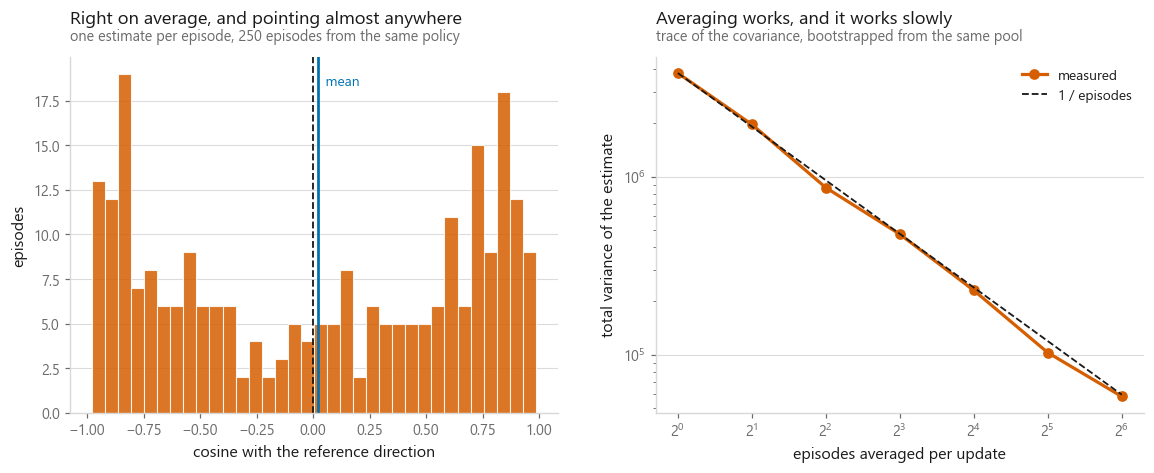

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.2))

ax = axes[0]
ax.hist(cosines, bins=34, color=style.HIGHLIGHT, alpha=0.85, edgecolor="white")
ax.axvline(0.0, color=style.INK, lw=1.2, ls="--")
ax.axvline(cosines.mean(), color=style.PALETTE[0], lw=1.8)
ax.text(cosines.mean(), ax.get_ylim()[1] * 0.92, "  mean", fontsize=9, color=style.PALETTE[0])
ax.set_xlabel("cosine with the reference direction")
ax.set_ylabel("episodes")
ax.grid(True, axis="y")
style.title(ax, "Right on average, and pointing almost anywhere",
            f"one estimate per episode, {len(pool)} episodes from the same policy")

ax = axes[1]
ax.plot(sizes, variance_by_size, color=style.HIGHLIGHT, lw=2.1,
        marker=style.MARKERS[0], markersize=6, label="measured")
ax.plot(sizes, variance_by_size[0] / sizes, color=style.INK, lw=1.2, ls="--",
        label="1 / episodes")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("episodes averaged per update")
ax.set_ylabel("total variance of the estimate")
ax.grid(True, axis="y")
ax.legend(fontsize=9)
style.title(ax, "Averaging works, and it works slowly",
            "trace of the covariance, bootstrapped from the same pool")
style.save(fig, FIG / "fig-02-noise.png")

The left panel is the problem in one picture. The estimator is unbiased, the
average of that histogram is the direction we want, and a sizeable share of
individual episodes point somewhere else entirely — some of them backwards.

The right panel is the only fix that needs no thought, and it is the expensive
one. Variance falls as one over the number of episodes, so halving the noise
costs four times the data. The dashed line is that rate. Everything in the next
section is an attempt to move the whole curve down instead of walking along it.

## 4. Three variance reductions, ablated

### (a) Reward-to-go

The plain estimator multiplies every $\nabla \log \pi(a_t \mid s_t)$ by the return
of the entire episode, including the rewards collected **before** step $t$. Those
rewards were already in the bank when the action was taken. The action cannot
have caused them.

Formally, for $k < t$ the reward $r_k$ is independent of $a_t$ given the past, so

$$\mathbb{E}\big[\nabla_\theta \log \pi_\theta(a_t \mid s_t)\, r_k\big] = 0$$

because the score function has zero mean under its own distribution. Those terms
contribute nothing to the expectation and everything they have to the variance.
Dropping them is free.

### (b) A learned baseline, which is the critic

The same zero-mean argument licenses something stronger. For any function $b(s)$
that does not look at the action,

$$\mathbb{E}_{a \sim \pi}\big[\nabla_\theta \log \pi_\theta(a \mid s)\, b(s)\big]
= b(s) \sum_a \nabla_\theta \pi_\theta(a \mid s)
= b(s)\, \nabla_\theta \! \sum_a \pi_\theta(a \mid s)
= b(s)\, \nabla_\theta 1 = 0$$

So subtracting $b(s_t)$ from the weight leaves the estimator unbiased whatever
$b$ is, and the natural choice is $b = V^{\pi}(s)$, the average return from that
state. The weight becomes an **advantage**:

$$A(s_t, a_t) = Q^{\pi}(s_t, a_t) - V^{\pi}(s_t)$$

and the question the update asks changes from "how good was this episode?" to
"was this action better than what usually happens from here?". In cart-pole every
reward is +1, so without a baseline every action ever taken gets made more likely
and the estimator has to work purely through differences in magnitude. With a
baseline, actions genuinely worse than average get pushed down.

Learning $V$ with a second network is what turns REINFORCE into
**actor-critic**: an actor that chooses, a critic that says what to expect. That
is where [11-08](../08-actor-critic-and-ppo/) starts.

### (c) Normalising the weights across the batch

The practical trick: standardise the weights over the whole batch, subtract the
mean and divide by the standard deviation. The mean subtraction is a baseline —
a crude one, constant across states, but a legitimate one. The division is
something else: it rescales the gradient, which is step-size control wearing a
variance-reduction costume. It matters, and it does not matter for the reason
people usually say.

I will measure the two effects separately, because raw variance can be lowered to
any level you like by multiplying the gradient by a small number. The scale-free
measure is the ratio of noise to signal:

$$\text{ratio} = \frac{\operatorname{tr}\operatorname{Cov}(\hat{g})}{\lVert \mathbb{E}[\hat{g}] \rVert^2}$$

which is unchanged by any rescaling and is what actually decides how many batches
you need before the average points somewhere useful.

In [12]:
CONFIGS = {
    "total return (plain)":      dict(reward_to_go=False, baseline=False, normalise=False),
    "reward-to-go":              dict(reward_to_go=True,  baseline=False, normalise=False),
    "reward-to-go + baseline":   dict(reward_to_go=True,  baseline=True,  normalise=False),
    "reward-to-go + normalised": dict(reward_to_go=True,  baseline=False, normalise=True),
    "all three":                 dict(reward_to_go=True,  baseline=True,  normalise=True),
}

rows = []
for name, cfg in CONFIGS.items():
    G = np.stack([gradient_vector(warm_policy, b, cfg["reward_to_go"],
                                  warm_value if cfg["baseline"] else None,
                                  cfg["normalise"])
                  for b in batches])
    mean_g = G.mean(axis=0)
    total_var = G.var(axis=0, ddof=1).sum()
    # ||mean||^2 is inflated by the noise in the mean itself, so take that back out
    # before dividing, otherwise the noisiest estimator flatters itself.
    signal = max(float(mean_g @ mean_g) - total_var / len(batches), 1e-12)
    rows.append({"weight": name, "variance": total_var,
                 "signal": signal, "noise / signal": total_var / signal})

variance_table = pd.DataFrame(rows)
print(f"measured on {len(batches)} independent batches of {EPISODES_PER_BATCH} episodes, "
      "all from the same pool")
print(variance_table.to_string(index=False, float_format=lambda v: f"{v:12.4g}"))

plain_ratio = variance_table["noise / signal"].iloc[0]
best_ratio = variance_table["noise / signal"].min()
best_weight = variance_table.loc[variance_table["noise / signal"].idxmin(), "weight"]
print(f"\nbest weight by noise-to-signal: {best_weight}")
print(f"ratio falls {plain_ratio / best_ratio:.1f}x against the plain estimator")

measured on 50 independent batches of 5 episodes, all from the same pool
                   weight     variance       signal  noise / signal
     total return (plain)    5.401e+05         8984           60.12
             reward-to-go    2.537e+05    2.996e+04           8.468
  reward-to-go + baseline    7.876e+04    4.147e+04           1.899
reward-to-go + normalised        135.5        59.23           2.287
                all three        139.1        66.61           2.089

best weight by noise-to-signal: reward-to-go + baseline
ratio falls 31.7x against the plain estimator


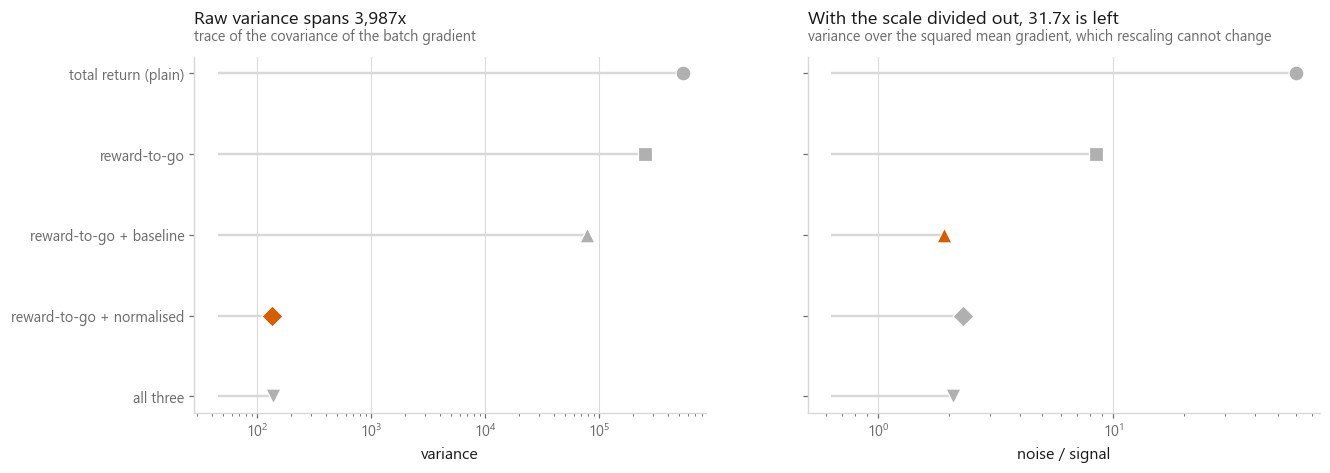

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.2), sharey=True)
names = list(variance_table["weight"])
y = np.arange(len(names))[::-1]

for ax, column, headline, sub in [
    (axes[0], "variance", f"Raw variance spans {variance_table['variance'].max() / variance_table['variance'].min():,.0f}x",
     "trace of the covariance of the batch gradient"),
    (axes[1], "noise / signal", f"With the scale divided out, {plain_ratio / best_ratio:.1f}x is left",
     "variance over the squared mean gradient, which rescaling cannot change"),
]:
    values = variance_table[column].to_numpy()
    colours = style.spot(len(values), int(np.argmin(values)))
    ax.hlines(y, values.min() / 3.0, values, color=style.RULE, lw=1.6, zorder=1)
    for i, (value, colour) in enumerate(zip(values, colours)):
        ax.scatter([value], [y[i]], color=colour, s=95, zorder=5,
                   marker=style.MARKERS[i], edgecolor="white", linewidth=0.8)
    ax.set_xscale("log")
    ax.set_xlabel(column)
    ax.grid(True, axis="x")
    ax.grid(False, axis="y")
    style.title(ax, headline, sub)

axes[0].set_yticks(y)
axes[0].set_yticklabels(names)
style.save(fig, FIG / "fig-03-variance.png")

The left panel is the number people quote and the right panel is the number that
decides how fast you learn. Read them together. Normalising the weights moves the
left panel a long way for a reason that has nothing to do with information —
dividing by a standard deviation shrinks everything — and the right panel is
where you see how much of that was real.

### The discount factor is a variance reducer too

$\gamma$ is usually introduced as a statement about preferences: how much the
agent cares about the future. In an episodic task like this one, where the
objective is literally "survive as many ticks as possible", the honest objective
has $\gamma = 1$ and anything less is a distortion of it.

It is used anyway, because of what it does to the weight on each decision. With
$\gamma = 1$ the reward-to-go at step $t$ sums every reward from $t$ to the end of
the episode, so a decision near the start carries the noise of hundreds of later
coin flips it barely influenced. With $\gamma < 1$ the sum is effectively cut off
after about $1/(1-\gamma)$ steps and the rest is multiplied away. Fewer noisy
terms per weight, less variance, and a bias against the objective you claimed to
care about. It is the same trade as any other shrinkage estimator.

In [14]:
rows = []
for gamma in (1.0, 0.999, 0.99, 0.95, 0.90):
    G = np.stack([gradient_vector(warm_policy, b, True, None, False, gamma=gamma)
                  for b in batches])
    mean_g = G.mean(axis=0)
    total_var = G.var(axis=0, ddof=1).sum()
    signal = max(float(mean_g @ mean_g) - total_var / len(batches), 1e-12)
    rows.append({"gamma": gamma, "effective horizon": np.inf if gamma == 1.0 else 1 / (1 - gamma),
                 "variance": total_var, "noise / signal": total_var / signal})

print("reward-to-go weights, no baseline, same episodes throughout")
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:12.4g}"))
print("\nthe raw variance falls as gamma falls, because the weights themselves shrink.")
print("whether that buys anything is the last column: it only helps if the mean")
print("gradient survives better than the noise does.")

reward-to-go weights, no baseline, same episodes throughout
       gamma  effective horizon     variance  noise / signal
           1                inf    9.628e+05           6.952
       0.999               1000    8.136e+05           7.052
        0.99                100    2.537e+05           8.468
        0.95                 20    2.544e+04           19.78
         0.9                 10         7248           71.07

the raw variance falls as gamma falls, because the weights themselves shrink.
whether that buys anything is the last column: it only helps if the mean
gradient survives better than the noise does.


### The ablation

Five configurations, two seeds each, and an identical budget of environment steps
for every one of them. Same network, same learning rate, same batch size, same
discount. The only difference is what goes into $w_t$.

Measuring in environment steps rather than episodes matters here more than it did
in [11-06](../06-deep-q-networks/). A configuration that learns well produces
five-hundred-step episodes, so its batches consume ten times the experience of a
failing configuration's batches. Counting episodes would hand the winner extra
data and then congratulate it.

In [15]:
SEEDS = (0, 1)

started = time.perf_counter()
runs, models = {}, {}

for name, cfg in CONFIGS.items():
    for seed in SEEDS:
        policy, _, history = train_pg(seed=seed, **cfg)
        runs[(name, seed)] = history
        models[(name, seed)] = policy
    final = np.mean([runs[(name, s)][-6:, 1].mean() for s in SEEDS])
    print(f"{name:<28} last batches, mean over seeds: {final:6.1f} steps"
          f"   [{time.perf_counter() - started:5.1f}s elapsed]")

print(f"\ntotal policy-gradient training time: {time.perf_counter() - started:.1f}s")

total return (plain)         last batches, mean over seeds:   87.3 steps   [ 10.9s elapsed]


reward-to-go                 last batches, mean over seeds:  239.0 steps   [ 21.9s elapsed]


reward-to-go + baseline      last batches, mean over seeds:  456.9 steps   [ 33.4s elapsed]


reward-to-go + normalised    last batches, mean over seeds:  394.0 steps   [ 44.4s elapsed]


all three                    last batches, mean over seeds:  409.6 steps   [ 56.1s elapsed]

total policy-gradient training time: 56.1s


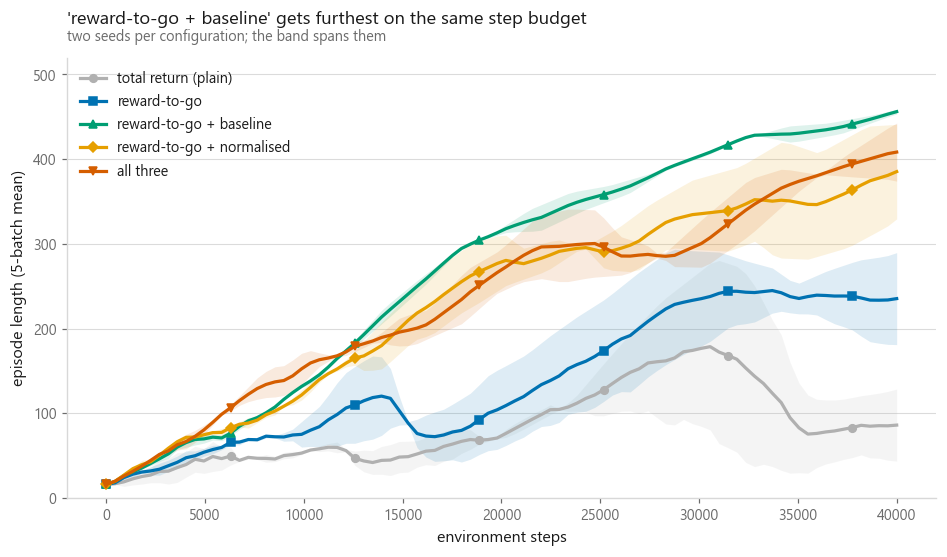

In [16]:
GRID = np.linspace(0, STEP_BUDGET, 90)


def band(histories, window=5):
    """Smooth each seed, put them on one step axis, return mean and the seed envelope."""
    curves = []
    for h in histories:
        smooth = pd.Series(h[:, 1]).rolling(window, min_periods=1).mean().to_numpy()
        curves.append(np.interp(GRID, h[:, 0], smooth))
    curves = np.stack(curves)
    return curves.mean(0), curves.min(0), curves.max(0)


scores = {name: np.mean([runs[(name, s)][-6:, 1].mean() for s in SEEDS]) for name in CONFIGS}
best_config = max(scores, key=scores.get)

colours = [style.NEUTRAL, style.PALETTE[0], style.PALETTE[2], style.PALETTE[1], style.HIGHLIGHT]

fig, ax = plt.subplots(figsize=(10.2, 5.2))
for i, name in enumerate(CONFIGS):
    mean, low, high = band([runs[(name, s)] for s in SEEDS])
    ax.fill_between(GRID, low, high, color=colours[i], alpha=0.13, linewidth=0)
    ax.plot(GRID, mean, color=colours[i], lw=2.1, label=name,
            marker=style.MARKERS[i], markevery=14, markersize=5)

ax.set_xlabel("environment steps")
ax.set_ylabel("episode length (5-batch mean)")
ax.set_ylim(0, 520)
ax.legend(loc="upper left", fontsize=9.5)
style.title(ax, f"'{best_config}' gets furthest on the same step budget",
            "two seeds per configuration; the band spans them")
style.save(fig, FIG / "fig-04-ablation.png")

In [17]:
summary = pd.DataFrame({
    "weight": list(CONFIGS),
    "first quarter": [np.mean([np.interp(GRID[:22], runs[(n, s)][:, 0], runs[(n, s)][:, 1]).mean()
                               for s in SEEDS]) for n in CONFIGS],
    "last quarter": [np.mean([np.interp(GRID[-22:], runs[(n, s)][:, 0], runs[(n, s)][:, 1]).mean()
                              for s in SEEDS]) for n in CONFIGS],
    "best batch": [np.mean([runs[(n, s)][:, 1].max() for s in SEEDS]) for n in CONFIGS],
    "seed spread (last)": [abs(runs[(n, SEEDS[0])][-6:, 1].mean()
                               - runs[(n, SEEDS[1])][-6:, 1].mean()) for n in CONFIGS],
    "updates used": [np.mean([len(runs[(n, s)]) for s in SEEDS]) for n in CONFIGS],
}).round(1)

print(f"mean episode length over {STEP_BUDGET:,} environment steps, averaged over seeds")
print(summary.to_string(index=False))

mean episode length over 40,000 environment steps, averaged over seeds
                   weight  first quarter  last quarter  best batch  seed spread (last)  updates used
     total return (plain)           41.0         101.2       222.3                84.5         146.5
             reward-to-go           53.8         240.2       296.1               112.5          89.0
  reward-to-go + baseline           78.3         458.5       500.0                 4.8          49.5
reward-to-go + normalised           79.0         384.1       500.0                86.9          51.5
                all three           96.8         419.2       474.8                64.5          49.5


Two things in that table are worth more attention than the ranking.

The first is the last column. Configurations that learn take longer episodes, and
a batch is a fixed number of episodes, so they get **fewer** gradient updates out
of the same experience. The winner is winning while being updated less often.

The second is the seed spread. With two seeds it is a hint rather than a result,
and I would not defend a gap between the top two configurations on this evidence.
The gap between the plain estimator and everything else is a different matter —
that one is wide enough, and the variance measurement in section 3 explains it
without appealing to luck.

One caution about reading the ablation as a direct picture of the variance table.
Adam divides each parameter's step by a running root-mean-square of its own
gradients, so the part of a variance reduction that is pure rescaling gets
absorbed by the optimiser and never shows up in the curve. What survives to the
learning curve is the part that changes the **direction** of the estimate, which
is why the right panel of the variance figure is the one that predicts these
results and the left panel is not.

### Next to the value method from 11-06

The obvious question after all this is whether the direct approach was worth it
on a problem where the value method already worked. It was not, and it is worth
being specific about why.

The comparison below is as close to fair as I can make it. Same environment, same
physics, same failure conditions, same episode cap, same budget of environment
steps, two seeds each. The DQN agent is [11-06](../06-deep-q-networks/)'s,
condensed: replay buffer, target network, decaying epsilon, everything else
unchanged.

In [18]:
class Replay:
    """The ring buffer from 11-06, condensed. Uniform sampling over everything stored."""

    def __init__(self, capacity, n_features, rng):
        self.s = np.zeros((capacity, n_features), dtype=np.float32)
        self.a = np.zeros(capacity, dtype=np.int64)
        self.r = np.zeros(capacity, dtype=np.float32)
        self.s2 = np.zeros((capacity, n_features), dtype=np.float32)
        self.done = np.zeros(capacity, dtype=np.float32)
        self.capacity, self.rng, self.n, self.i = capacity, rng, 0, 0

    def add(self, s, a, r, s2, done):
        i = self.i
        self.s[i], self.a[i], self.r[i], self.s2[i], self.done[i] = s, a, r, s2, done
        self.i = (i + 1) % self.capacity
        self.n = min(self.n + 1, self.capacity)

    def sample(self, k):
        idx = self.rng.integers(self.n, size=k)
        return (torch.from_numpy(self.s[idx]), torch.from_numpy(self.a[idx]),
                torch.from_numpy(self.r[idx]), torch.from_numpy(self.s2[idx]),
                torch.from_numpy(self.done[idx]))


def make_q_net(hidden=64):
    return nn.Sequential(
        nn.Linear(CartPole.n_features, hidden), nn.ReLU(),
        nn.Linear(hidden, hidden), nn.ReLU(),
        nn.Linear(hidden, CartPole.n_actions),
    )


def train_dqn(step_budget=STEP_BUDGET, seed=SEED, lr=1e-3, gamma=GAMMA, batch_size=64,
              capacity=10_000, learn_start=500, target_sync=200,
              eps_end=0.05, eps_decay=1500.0, max_steps=MAX_STEPS):
    """11-06's agent, given exactly the same number of environment steps as above."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    env = CartPole(rng)

    online, frozen = make_q_net(), make_q_net()
    frozen.load_state_dict(online.state_dict())
    opt = torch.optim.Adam(online.parameters(), lr=lr)
    buf = Replay(capacity, env.n_features, rng)

    steps = updates = 0
    history = []

    while steps < step_budget:
        state = env.reset()
        length = 0
        for _ in range(max_steps):
            epsilon = eps_end + (1.0 - eps_end) * np.exp(-steps / eps_decay)
            if rng.random() < epsilon:
                action = int(rng.integers(env.n_actions))
            else:
                with torch.no_grad():
                    action = int(online(torch.from_numpy(state).unsqueeze(0)).argmax())

            next_state, reward, done = env.step(action)
            buf.add(state, action, reward, next_state, float(done))
            state = next_state
            steps += 1
            length += 1

            if buf.n >= learn_start:
                s, a, r, s2, d = buf.sample(batch_size)
                with torch.no_grad():
                    y = r + gamma * (1.0 - d) * frozen(s2).max(1).values
                q = online(s).gather(1, a.unsqueeze(1)).squeeze(1)
                loss = nn.functional.smooth_l1_loss(q, y)
                opt.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(online.parameters(), 10.0)
                opt.step()
                updates += 1

            if done or steps >= step_budget:
                break
        history.append((steps, float(length)))

    return online, np.array(history), updates


started = time.perf_counter()
dqn_runs, dqn_models = {}, {}
for seed in SEEDS:
    net, history, updates = train_dqn(seed=seed)
    dqn_runs[seed] = history
    dqn_models[seed] = net
    print(f"DQN seed {seed}: {updates:,} gradient updates from "
          f"{int(history[-1, 0]):,} environment steps "
          f"[{time.perf_counter() - started:5.1f}s elapsed]")

pg_updates = np.mean([len(runs[(best_config, s)]) for s in SEEDS])
print(f"\npolicy gradient used about {pg_updates:.0f} updates on the same experience")
print("DQN replays each stored transition many times; REINFORCE sees each one once")

DQN seed 0: 39,501 gradient updates from 40,000 environment steps [123.6s elapsed]


DQN seed 1: 39,501 gradient updates from 40,000 environment steps [254.7s elapsed]

policy gradient used about 50 updates on the same experience
DQN replays each stored transition many times; REINFORCE sees each one once


In [19]:
def evaluate_policy(policy, seed, n_episodes=10, max_steps=MAX_STEPS, greedy=False):
    """Mean episode length under the learned policy, sampled or taken greedily."""
    rng = np.random.default_rng(seed)
    env = CartPole(rng)
    lengths = []
    for _ in range(n_episodes):
        state = env.reset()
        length = 0
        for _ in range(max_steps):
            with torch.no_grad():
                probs = torch.softmax(policy(torch.from_numpy(state).unsqueeze(0)),
                                      dim=1).numpy()[0]
            action = int(probs.argmax()) if greedy else sample_action(probs, rng)
            state, _, done = env.step(action)
            length += 1
            if done:
                break
        lengths.append(length)
    return float(np.mean(lengths))


def evaluate_q(net, seed, n_episodes=10, max_steps=MAX_STEPS):
    rng = np.random.default_rng(seed)
    env = CartPole(rng)
    lengths = []
    for _ in range(n_episodes):
        state = env.reset()
        length = 0
        for _ in range(max_steps):
            with torch.no_grad():
                action = int(net(torch.from_numpy(state).unsqueeze(0)).argmax())
            state, _, done = env.step(action)
            length += 1
            if done:
                break
        lengths.append(length)
    return float(np.mean(lengths))


comparison = pd.DataFrame([
    {"agent": f"policy gradient, {best_config} (sampled)",
     "mean episode length": np.mean([evaluate_policy(models[(best_config, s)], 500 + s)
                                     for s in SEEDS])},
    {"agent": f"policy gradient, {best_config} (argmax)",
     "mean episode length": np.mean([evaluate_policy(models[(best_config, s)], 500 + s, greedy=True)
                                     for s in SEEDS])},
    {"agent": "DQN from 11-06 (greedy)",
     "mean episode length": np.mean([evaluate_q(dqn_models[s], 500 + s) for s in SEEDS])},
]).round(1)

print(f"ten fresh episodes per seed, two seeds, after {STEP_BUDGET:,} environment steps each")
print(comparison.to_string(index=False))
print("\nthe policy-gradient agent is evaluated by sampling, which is how it behaves;")
print("taking its argmax is a different policy and is reported separately")

ten fresh episodes per seed, two seeds, after 40,000 environment steps each
                                             agent  mean episode length
policy gradient, reward-to-go + baseline (sampled)                476.6
 policy gradient, reward-to-go + baseline (argmax)                492.8
                           DQN from 11-06 (greedy)                  9.5

the policy-gradient agent is evaluated by sampling, which is how it behaves;
taking its argmax is a different policy and is reported separately


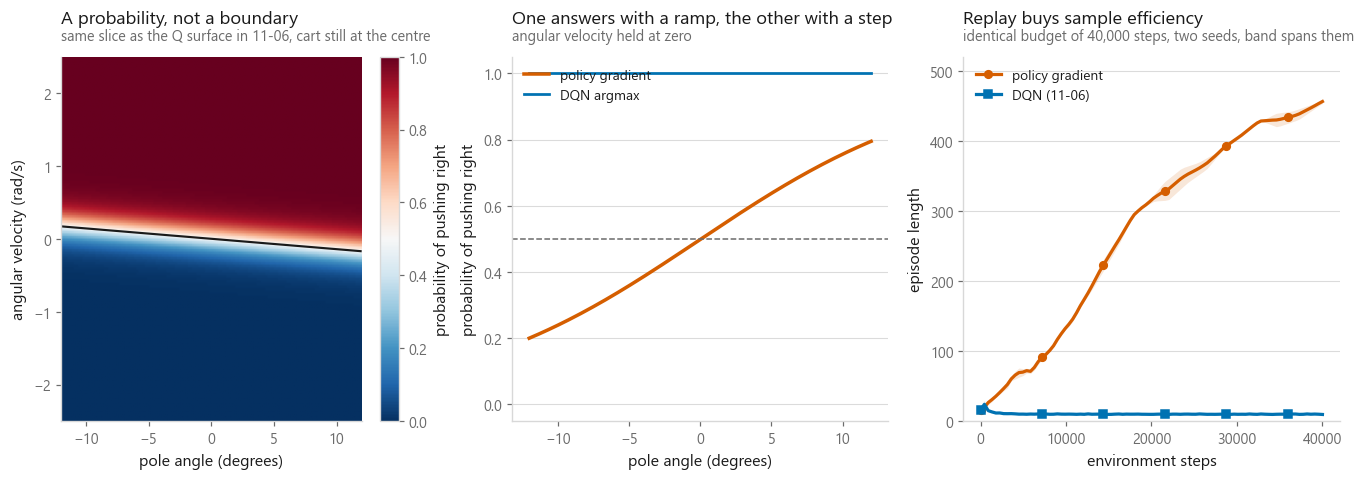

In [20]:
angles = np.linspace(-CartPole.angle_limit, CartPole.angle_limit, 140)
rates = np.linspace(-2.5, 2.5, 140)
AA, RR = np.meshgrid(angles, rates)
grid = np.stack([np.zeros(AA.size), np.zeros(AA.size), AA.ravel(), RR.ravel()],
                axis=1).astype(np.float32)

best_policy = models[(best_config, 0)]
with torch.no_grad():
    right = torch.softmax(best_policy(torch.from_numpy(grid)), dim=1)[:, 1].numpy()
right = right.reshape(AA.shape)

cut_states = np.stack([np.zeros_like(angles), np.zeros_like(angles),
                       angles, np.zeros_like(angles)], axis=1).astype(np.float32)
with torch.no_grad():
    cut_probs = torch.softmax(best_policy(torch.from_numpy(cut_states)), dim=1)[:, 1].numpy()
    cut_q = dqn_models[0](torch.from_numpy(cut_states)).argmax(dim=1).numpy()

extent = [np.degrees(angles[0]), np.degrees(angles[-1]), rates[0], rates[-1]]

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.3))

ax = axes[0]
im = ax.imshow(right, origin="lower", extent=extent, aspect="auto",
               cmap="RdBu_r", vmin=0.0, vmax=1.0)
ax.contour(np.degrees(AA), RR, right, levels=[0.5], colors=[style.INK], linewidths=1.4)
ax.set_xlabel("pole angle (degrees)")
ax.set_ylabel("angular velocity (rad/s)")
ax.grid(False)
fig.colorbar(im, ax=ax, label="probability of pushing right")
style.title(ax, "A probability, not a boundary",
            "same slice as the Q surface in 11-06, cart still at the centre")

ax = axes[1]
ax.plot(np.degrees(angles), cut_probs, color=style.HIGHLIGHT, lw=2.3, label="policy gradient")
ax.step(np.degrees(angles), cut_q, color=style.PALETTE[0], lw=1.8, where="mid",
        label="DQN argmax")
ax.axhline(0.5, color=style.MUTED, lw=1.0, ls="--")
ax.set_xlabel("pole angle (degrees)")
ax.set_ylabel("probability of pushing right")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9, loc="upper left")
style.title(ax, "One answers with a ramp, the other with a step",
            "angular velocity held at zero")

ax = axes[2]
mean, low, high = band([runs[(best_config, s)] for s in SEEDS])
ax.fill_between(GRID, low, high, color=style.HIGHLIGHT, alpha=0.15, linewidth=0)
ax.plot(GRID, mean, color=style.HIGHLIGHT, lw=2.1, label="policy gradient",
        marker=style.MARKERS[0], markevery=16, markersize=5)
mean, low, high = band([dqn_runs[s] for s in SEEDS], window=15)
ax.fill_between(GRID, low, high, color=style.PALETTE[0], alpha=0.15, linewidth=0)
ax.plot(GRID, mean, color=style.PALETTE[0], lw=2.1, label="DQN (11-06)",
        marker=style.MARKERS[1], markevery=16, markersize=5)
ax.set_xlabel("environment steps")
ax.set_ylabel("episode length")
ax.set_ylim(0, 520)
ax.legend(fontsize=9, loc="upper left")
style.title(ax, "Replay buys sample efficiency",
            f"identical budget of {STEP_BUDGET:,} steps, two seeds, band spans them")
style.save(fig, FIG / "fig-05-versus-dqn.png")

The middle panel is the structural difference, and it holds no matter who wins
the race. DQN's policy is a step function: on one side of the boundary it pushes
right with probability one, on the other side left, and there is nothing in
between. The policy-gradient agent's answer is a probability that slides from one
action to the other. Near the boundary — where the pole is nearly upright and the
choice barely matters — it is close to a coin flip. That is exactly the shape the
corridor in section 1 needed and could not get from a value function.

The right panel is the cost. DQN takes a gradient step on every environment step
and each stored transition is replayed dozens of times. REINFORCE collects a
batch, takes one step, and throws the data away, because after the update the
data came from a policy that no longer exists. On-policy means what it says. That
is the trade: expressiveness and a direct objective, paid for in samples.

## 5. Step size, and why PPO exists

One problem is left and it is the one the modern algorithms are built around.

A supervised model that takes a bad step gets a worse loss and recovers on the
next batch, because the data is still there. A policy that takes a bad step
changes the distribution it collects from. Wreck the policy and the next batch is
collected by the wrecked policy — worse data, from which you cannot recover the
behaviour you had, because there is no replay buffer holding the old trajectories
and no way to undo the update.

The reason this is hard to guard against is that step size in parameter space
says almost nothing about how much the **policy** moved. The same distance in
$\theta$ can be a rounding error early on and a total rewrite once the logits are
large, because softmax saturates. The measurement below takes a trained policy,
steps it along its own gradient direction by a range of distances, and records
both how far the distribution moved — mean KL divergence over states it actually
visits — and what the resulting policy scores.

In [21]:
probe_rng = np.random.default_rng(99)
probe = collect(best_policy, CartPole(probe_rng), probe_rng, 10, 300)
direction = gradient_vector(best_policy, probe, True, None, True)
direction = direction / np.linalg.norm(direction)

reference_states, _ = flat(probe)
with torch.no_grad():
    old_log = torch.log_softmax(best_policy(reference_states), dim=1)
saved = [p.detach().clone() for p in best_policy.parameters()]


def set_offset(size):
    """theta <- theta_saved + size * unit gradient direction."""
    offset = 0
    with torch.no_grad():
        for p, base in zip(best_policy.parameters(), saved):
            n = p.numel()
            chunk = torch.from_numpy(direction[offset:offset + n].astype(np.float32))
            p.copy_(base + size * chunk.reshape(p.shape))
            offset += n


rows = []
for size in (0.0, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0):
    set_offset(size)
    with torch.no_grad():
        new_log = torch.log_softmax(best_policy(reference_states), dim=1)
    kl = float((old_log.exp() * (old_log - new_log)).sum(1).mean())
    rows.append({"step in parameter space": size,
                 "mean KL from the old policy": kl,
                 "episode length after the step": evaluate_policy(best_policy, 4242, n_episodes=8,
                                                                  max_steps=400)})
set_offset(0.0)   # put the policy back before anything else uses it

print("one step along the estimated gradient, from a trained policy")
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:10.4g}"))
print("\nthe first row is the policy untouched, and is the number to compare against")

one step along the estimated gradient, from a trained policy
 step in parameter space  mean KL from the old policy  episode length after the step
                       0                            0                          368.8
                    0.03                    0.0003014                          397.5
                     0.1                     0.003374                          368.6
                     0.3                      0.03082                          387.5
                       1                       0.3273                          138.4
                       3                        1.658                          9.375
                      10                        2.151                          9.375

the first row is the policy untouched, and is the number to compare against


Small steps do nothing measurable. Large steps move the distribution a long way
and take the score with them. Somewhere in between is a step that helps, and the
distance that lands there is a property of where the policy currently is, not a
constant you can tune once and keep.

That is the observation behind the whole modern line of work. If parameter
distance is the wrong currency, budget the update in **policy** distance instead:

**TRPO** solves for the largest step whose KL divergence from the old policy stays
under a fixed limit. Correct, and it needs second-order machinery to do it.

**PPO** gets most of the same effect with a first-order trick. Write the update in
terms of the probability ratio $r_t(\theta) = \pi_\theta(a_t \mid s_t) /
\pi_{\theta_{\text{old}}}(a_t \mid s_t)$, which is 1 before the update, and clip
it to $[1-\epsilon, 1+\epsilon]$ inside the objective. Once the ratio leaves that
window the gradient goes flat, so no amount of enthusiasm from a single advantage
estimate can push the policy further than the clip allows. The same ratio also
makes it legal to take several gradient steps on one batch, which is where most
of PPO's sample efficiency comes from.

That, together with the critic from section 4, is
[11-08](../08-actor-critic-and-ppo/).

## Cheat sheet

| | |
|---|---|
| **Use it when** | The best policy is stochastic, the actions are continuous, or you want to optimise behaviour directly rather than derive it from a value |
| **Avoid it when** | Samples are expensive. On-policy data is used once and discarded; [DQN](../06-deep-q-networks/) replays every transition many times |
| **The estimator** | $\nabla J = \mathbb{E}\big[\sum_t \nabla \log \pi(a_t \mid s_t)\, w_t\big]$, unbiased for any $w_t$ built from the future and a baseline that ignores the action |
| **Must have** | Reward-to-go at minimum, then a learned baseline. Without a baseline every action taken is made more likely and only magnitudes separate them |
| **Main dials** | Learning rate, episodes per update, discount, and what goes into $w_t$ |
| **Off-policy?** | No. That is the whole difficulty, and the reason PPO's ratio exists |
| **Watch out** | One oversized update destroys the policy and the next batch is collected by the damaged one. There is nothing to roll back to |
| **Sanity check** | Print the fraction of your gradient estimates that point the wrong way before blaming the learning rate |
| **Next** | [Actor-critic and PPO](../08-actor-critic-and-ppo/), which is a learned baseline plus a limit on how far one update may move |

## What to remember

1. An `argmax` over a value function is deterministic, discontinuous, and needs a
   search when the action is continuous. Parameterising the policy removes all
   three problems at once.
2. When the agent cannot tell two states apart, the best policy it can represent
   may be genuinely random. No value function can produce that.
3. The log-derivative trick is $\nabla p = p \nabla \log p$, and it converts a
   gradient of an expectation into an expectation of a gradient.
4. The dynamics drop out of that gradient because they do not depend on $\theta$.
   Nothing here needs a model of the world.
5. REINFORCE is unbiased and extremely noisy. Averaging cuts the variance as one
   over the number of episodes, which is the slowest fix available.
6. Reward-to-go removes terms whose expectation is zero. It costs nothing and
   should always be on.
7. Subtracting any baseline that ignores the action keeps the estimator unbiased.
   Learning that baseline is what makes the method actor-critic.
8. Normalising the batch is two things wearing one name: a crude baseline, and a
   rescale that mostly controls the step size. Measure variance relative to the
   mean gradient or you will credit the rescale for work it did not do.
9. A smaller discount shortens the horizon each weight has to sum over, which
   lowers variance and biases the objective. That trade is deliberate.
10. Distance in parameter space does not translate to distance in policy space,
    and a policy that gets wrecked collects its own next batch. Limiting the
    update in KL, or clipping the probability ratio, is what PPO is for.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [11-08 Actor-critic and PPO](../08-actor-critic-and-ppo/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#ReinforcementLearning` `#PolicyGradient` `#REINFORCE` `#ActorCritic` `#PPO`
`#PyTorch` `#MachineLearning` `#CartPole` `#MLTutorial` `#LearnMachineLearning`